# Compare TAD annotations - Figure 1C
- 20Kb resolution.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import bioframe as bf
from sklearn.metrics import adjusted_rand_score
from tqdm.auto import tqdm
from pathlib import Path

In [2]:
plt.rcParams.update({'pdf.fonttype': 42,
                     'ps.fonttype': 42})
sns.set_context('talk')

## Set parameters

In [4]:
RESOLUTION = 20_000
MAX_BIN_DIST = 2_000_000 // RESOLUTION
REPO = Path('/groups/gerlich/labinfo/Papers/2025_ReplChromConf/analysis/assets/tads_downsampled/')
CONDITIONS = ('WT_G2', 'WT_G1', 'Prometa', 'dSororin_G2', 'WT_G2_BR1n2', 'WT_G2_BR3')

## Read OnTAD domains

In [5]:
def read_ontad_annot(fname):
    if not Path(fname).exists():
        return None
    df = bf.read_table(fname, schema='bedpe')\
           .rename(columns={'name': 'TADlevel', 'score': 'TADmean', 'strand1': 'TADscore'})\
           .drop(['strand2', 'chrom2', 'start2', 'end2'], axis=1)\
           .rename(columns={f"{s}1": s for s in ('chrom', 'start', 'end')})\
           .reset_index(names='tad_id')
    return df

In [6]:
ontad_domains = {cond: read_ontad_annot(REPO / f"nested_tads.{cond}.bedpe")
                 for cond in CONDITIONS}

## Convert Hi-C pixels into cluster annotations

Following https://github.com/anlin00007/OnTAD_figures/blob/master/Reproducibility.ipynb

In [8]:
chromsizes = bf.fetch_chromsizes('hg19')
bins = bf.binnify(chromsizes, RESOLUTION, rel_ids=True)

In [9]:
def annot_to_bins(annot, bins):
    if annot is None:
        return None
    overlap = bf.overlap(annot, bins, how='left')
    bin_starts = overlap.groupby('tad_id')['rel_id_'].min().rename('bin_start').reset_index()
    bin_ends = overlap.groupby('tad_id')['rel_id_'].max().rename('bin_end').reset_index()
    bin_tads = pd.merge(pd.merge(bin_starts, bin_ends),
                        annot[['chrom', 'TADlevel', 'tad_id']],
                        on='tad_id',
                        how='left')
    bin_tads = bin_tads[['bin_start', 'bin_end', 'chrom', 'TADlevel', 'tad_id']]
    bin_tads['length'] = bin_tads['bin_end'] - bin_tads['bin_start']
    return bin_tads

In [10]:
ontad_bin_domains = {condition: annot_to_bins(annot, bins)
                     for condition, annot in ontad_domains.items()}

After converting TAD coordinates to bins, we will get Hi-C pixels with assigned innermost TADs (per chromosome).

In [11]:
def pixel_to_tad_id(tads, chrom_bin_len, max_bin_dist=200):
    # based on TADtoCluster function from https://github.com/anlin00007/OnTAD_figures/blob/master/Reproducibility.ipynb
    if tads is None:
        return None
    tmat = np.zeros((chrom_bin_len, chrom_bin_len), dtype='int')
    sorted_tads = tads.sort_values('length', ascending=False)\
                      .sort_values('TADlevel', ascending=True, kind='stable')

    for i, tad in enumerate(sorted_tads.itertuples()):
        tmat[tad.bin_start: tad.bin_end, tad.bin_start: tad.bin_end] = i + 1

    a = []
    for offset in range(0, min(max_bin_dist, chrom_bin_len - 1)):
        ta = [row[rown + offset]
              for rown, row in enumerate(tmat) if rown + offset < len(row)]
        a += ta
    return np.asarray(a)

In [12]:
chrom_bin_lengths = bins.groupby('chrom')['rel_id'].max()

In [13]:
ontad_pixel_clusters = dict()
for condition, annot in tqdm(ontad_bin_domains.items()):
    ontad_pixel_clusters[condition] = dict()
    for chrom, tads in annot.groupby('chrom'):
        ontad_pixel_clusters[condition][chrom] = pixel_to_tad_id(tads,
                                                                 chrom_bin_lengths[chrom],
                                                                 max_bin_dist=MAX_BIN_DIST)

  0%|          | 0/6 [00:00<?, ?it/s]

## Set up pairs for comparison

In [14]:
comparison_pairs = [('WT_G2', cond)
                    for cond in CONDITIONS
                    if not cond.startswith('WT_G2')] \
                   + [('WT_G2_BR1n2', 'WT_G2_BR3')]

In [15]:
for pair in comparison_pairs:
    print(pair[0], pair[1], sep='\t')

WT_G2	WT_G1
WT_G2	Prometa
WT_G2	dSororin_G2
WT_G2_BR1n2	WT_G2_BR3


## Calculate adjusted Rand index (ARI)

In [16]:
def make_label_replicate(cond1, cond2):
    if 'BR' in cond1:
        label = 'replicates'
        replicate = 'replicate'
    else:
        label = cond2
        replicate = 'condition'
    return label, replicate

In [17]:
def calc_ari(clusters_collection, conds_to_compare):
    record_holder = list()
    for cond1, cond2 in tqdm(conds_to_compare):
        label, replicate = make_label_replicate(cond1, cond2)
        for chrom, data1 in clusters_collection[cond1].items():
            data2 = clusters_collection[cond2].get(chrom)
            if data1 is None or data2 is None:
                ari = None
            else:
                ari = adjusted_rand_score(data1, data2)
            record = {"chrom": chrom,
                      'cond1': cond1,
                      'cond2': cond2,
                      'ari': ari,
                      'label': label,
                      'replicate': replicate}
            record_holder.append(record)
            
    ari_results = pd.DataFrame.from_records(record_holder)
    return ari_results

In [18]:
ari_results = calc_ari(ontad_pixel_clusters, comparison_pairs)

  0%|          | 0/4 [00:00<?, ?it/s]

## Plot ARI results

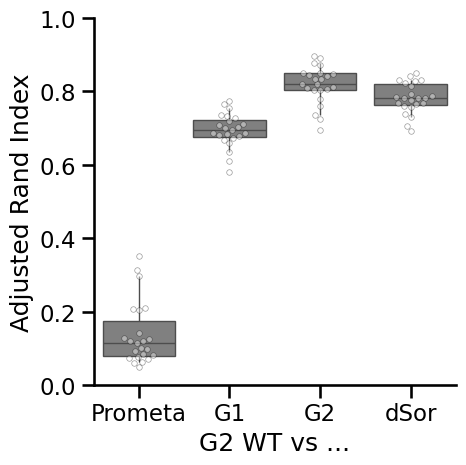

In [23]:
df = ari_results.query('chrom != "chrY"')
with sns.plotting_context('talk'):
    plt.figure(figsize=(5, 5))
    sns.boxplot(data=df,
                y='ari',
                x='label',
                legend=False,
                color='.5',
                saturation=1,
                order=['Prometa', 'WT_G1', 'replicates', 'dSororin_G2'],
                fliersize=0,
                whis=(5, 95),
                showcaps=False)
    sns.swarmplot(data=df,
                  y='ari',
                  x='label',
                  alpha=.4,
                  legend=False,
                  color='w',
                  edgecolor='k',
                  linewidth=.5,
                  size=4)
    plt.xticks(ticks=range(4), labels=['Prometa', 'G1', 'G2', 'dSor'])
    plt.xlabel('G2 WT vs ...')
    plt.ylabel('Adjusted Rand Index')
    plt.ylim(0, 1)
    sns.despine()
    plt.tight_layout()